<a href="https://colab.research.google.com/github/ralucamicu/FineTuning-LLMs-for-Cybersecurity-Knowledge/blob/master/finetune_llama32_secqa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning Llama-3.2-3B for Cybersecurity Knowledge


## scheme

```
                       ┌──────────────┐
            ┌──────────┤   SEC-QA v1  │  (eval only — held out)
            │          └──────────────┘
            │
        ┌───▼─────────┐                          ┌─────────────────┐
        │ Llama-3.2-3B│◄─────── fine-tune ───────│ CyberMetric 10K │
        └───┬─────────┘                          └─────────────────┘
            │
            │          ┌──────────────┐
            └──────────┤   SEC-QA v2  │  (eval only — held out)
                       └──────────────┘


## 1. Environment Setup

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch>=2.8.0" "triton>=3.4.0" {_numpy} {_pil} torchvision bitsandbytes "transformers==4.56.2" \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
    !pip install --quiet datasets pandas matplotlib
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps transformers==4.56.2 "tokenizers>=0.22.0,<=0.23.0" trl==0.22.2 unsloth unsloth_zoo
!uv pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install --quiet datasets pandas matplotlib

In [2]:
import json
import re
import random

import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset, load_dataset
from tqdm.auto import tqdm

random.seed(3407)
torch.manual_seed(3407)
print("Setup complete.")

Setup complete.


## 2. Load Evaluation Datasets — SecQA v1 & v2

In [3]:
secqa_v1 = load_dataset("zefang-liu/secqa", "secqa_v1", split="test")
secqa_v2 = load_dataset("zefang-liu/secqa", "secqa_v2", split="test")
print(f"SecQA v1: {len(secqa_v1)} questions")
print(f"SecQA v2: {len(secqa_v2)} questions")
print("\nExample SecQA v1 entry:")
print(secqa_v1[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

secqa_v1_dev.csv: 0.00B [00:00, ?B/s]

secqa_v1_val.csv: 0.00B [00:00, ?B/s]

secqa_v1_test.csv: 0.00B [00:00, ?B/s]

...

secqa_v2_test.csv: 0.00B [00:00, ?B/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/10 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

SecQA v1: 110 questions
SecQA v2: 100 questions

Example SecQA v1 entry:
{'Question': 'Which of the following is a common indicator of an SQL injection attack?', 'A': 'Frequent changes in user account permissions.', 'B': 'Decreased performance of endpoint protection systems.', 'C': 'Unusually high data upload rates to a web server.', 'D': 'Sudden uptick in SQL queries, far beyond the usual baseline for the application.', 'Answer': 'D', 'Explanation': 'A sudden increase in SQL queries beyond the normal operational baseline can indicate an SQL injection attack, where malicious SQL statements are inserted into an entry field for execution.'}


## 3. Load Training Dataset — CyberMetric 10K


In [4]:
!wget -q https://raw.githubusercontent.com/cybermetric/CyberMetric/main/CyberMetric-10000-v1.json -O CyberMetric-10000.json

with open("CyberMetric-10000.json", "r") as f:
    cm_raw = json.load(f)

cm_questions = cm_raw["questions"] if isinstance(cm_raw, dict) else cm_raw
print(f"CyberMetric-10000 loaded: {len(cm_questions)} questions")
print("\nExample entry:")
print(cm_questions[0])

CyberMetric-10000 loaded: 10180 questions

Example entry:
{'question': 'Which of the following refers to the secrecy of information?', 'answers': {'A': 'Availability', 'B': 'Authentication', 'C': 'Integrity', 'D': 'Confidentiality'}, 'solution': 'D'}


## 4. Load the Base Model — Llama-3.2-3B-Instruct (4-bit QLoRA)


In [5]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 2048
BASE_MODEL = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)
print(f"Loaded {BASE_MODEL}")
print(f"VRAM after load: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.1: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Loaded unsloth/Llama-3.2-3B-Instruct-bnb-4bit
VRAM after load: 2.11 GB


## 5. Baseline Evaluation (no fine-tune)


In [6]:
def build_mcq_prompt(item):
    """Build a chat prompt that asks the model to answer with a single letter."""
    question = item["Question"]
    choices = f"A) {item['A']}\nB) {item['B']}\nC) {item['C']}\nD) {item['D']}"

    user_msg = (
        f"Answer the following cybersecurity multiple-choice question. "
        f"Reply with ONLY the letter (A, B, C, or D) of the correct answer.\n\n"
        f"Question: {question}\n\n"
        f"Options:\n{choices}\n\n"
        f"Answer:"
    )

    messages = [{"role": "user", "content": user_msg}]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return prompt


def parse_answer_letter(text):
    """Extract the first A/B/C/D letter from the model's output."""
    match = re.search(r"\b([ABCD])\b", text.upper())
    return match.group(1) if match else None


def evaluate_mcq(model, tokenizer, dataset, name="dataset"):
    """Evaluate model on an MCQ benchmark. Returns accuracy and per-question results."""
    FastLanguageModel.for_inference(model)  # 2x faster generation
    correct = 0
    results = []

    for item in tqdm(dataset, desc=f"Evaluating {name}"):
        prompt = build_mcq_prompt(item)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens = 8,
                do_sample = False,
                pad_token_id = tokenizer.eos_token_id,
            )

        generated = tokenizer.decode(
            output_ids[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True,
        )
        pred = parse_answer_letter(generated)
        truth = item["Answer"]
        is_correct = (pred == truth)
        if is_correct:
            correct += 1
        results.append({
            "question": item["Question"][:80] + "...",
            "predicted": pred,
            "correct": truth,
            "is_correct": is_correct,
            "raw_output": generated.strip(),
        })

    accuracy = correct / len(dataset)
    print(f"  {name}: {correct}/{len(dataset)} = {accuracy:.2%}")
    return accuracy, results

In [10]:
print("=" * 45)
print("Baseline Llama-3.2-3B-Instruct (no fine-tune)")
print("=" * 45)

baseline_secqa_v1, baseline_results_v1 = evaluate_mcq(
    model, tokenizer, secqa_v1, "SecQA v1"
)
baseline_secqa_v2, baseline_results_v2 = evaluate_mcq(
    model, tokenizer, secqa_v2, "SecQA v2"
)

baseline_results = {
    "SecQA v1": baseline_secqa_v1,
    "SecQA v2": baseline_secqa_v2,
}
print("\nBaseline summary:")
for k, v in baseline_results.items():
    print(f"  {k:10s}: {v:.2%}")

Baseline Llama-3.2-3B-Instruct (no fine-tune)


Evaluating SecQA v1:   0%|          | 0/110 [00:00<?, ?it/s]

  SecQA v1: 107/110 = 97.27%


Evaluating SecQA v2:   0%|          | 0/100 [00:00<?, ?it/s]

  SecQA v2: 95/100 = 95.00%

Baseline summary:
  SecQA v1  : 97.27%
  SecQA v2  : 95.00%


## 6. Apply LoRA Adapters for Fine-Tuning

In [11]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.4f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable: 24,313,856 / Total: 1,827,777,536 (1.3302%)


## 7. Format CyberMetric and Fine-Tune

In [12]:
def format_cybermetric_for_training(item):
    """Format one CyberMetric question as an instruction-tuning example."""
    question = item["question"]
    answers = item["answers"]
    correct = item["solution"]

    choices = "\n".join([f"{k}) {v}" for k, v in answers.items()])
    user_msg = (
        f"Answer the following cybersecurity multiple-choice question. "
        f"Reply with ONLY the letter (A, B, C, or D) of the correct answer.\n\n"
        f"Question: {question}\n\n"
        f"Options:\n{choices}\n\n"
        f"Answer:"
    )
    assistant_msg = correct

    messages = [
        {"role": "user",      "content": user_msg},
        {"role": "assistant", "content": assistant_msg},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    return {"text": text}

train_data = [format_cybermetric_for_training(q) for q in cm_questions]
train_dataset = Dataset.from_list(train_data)
print(f"Training examples: {len(train_dataset)}")
print("\nFirst training example:\n")
print(train_dataset[0]["text"][:500])

Training examples: 10180

First training example:

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 09 Jun 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

Answer the following cybersecurity multiple-choice question. Reply with ONLY the letter (A, B, C, or D) of the correct answer.

Question: Which of the following refers to the secrecy of information?

Options:
A) Availability
B) Authentication
C) Integrity
D) Confidentiality

Answer:<|eot_id|><|start_header_id|>assistant<|e


In [13]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,    # effective batch = 8
        warmup_steps = 50,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 25,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        save_strategy = "no",
        report_to = "none",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/10180 [00:00<?, ? examples/s]

In [14]:
gpu_info = torch.cuda.get_device_properties(0)
start_gpu = torch.cuda.memory_reserved() / 1024**3
print(f"GPU: {gpu_info.name}, Total VRAM: {gpu_info.total_memory/1024**3:.1f} GB")
print(f"VRAM used before training: {start_gpu:.2f} GB")

trainer_stats = trainer.train()

used_gpu = torch.cuda.max_memory_reserved() / 1024**3
print(f"\nPeak VRAM during training: {used_gpu:.2f} GB")
print(f"Training time: {trainer_stats.metrics['train_runtime']/60:.1f} minutes")

GPU: Tesla T4, Total VRAM: 14.6 GB
VRAM used before training: 2.38 GB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,180 | Num Epochs = 1 | Total steps = 1,273
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Step,Training Loss
25,2.806600
50,1.143900
75,1.051100
100,0.888800
125,0.885000
150,0.851700
175,0.842400
200,0.845600
225,0.832600
250,0.825200



Peak VRAM during training: 6.07 GB
Training time: 38.4 minutes


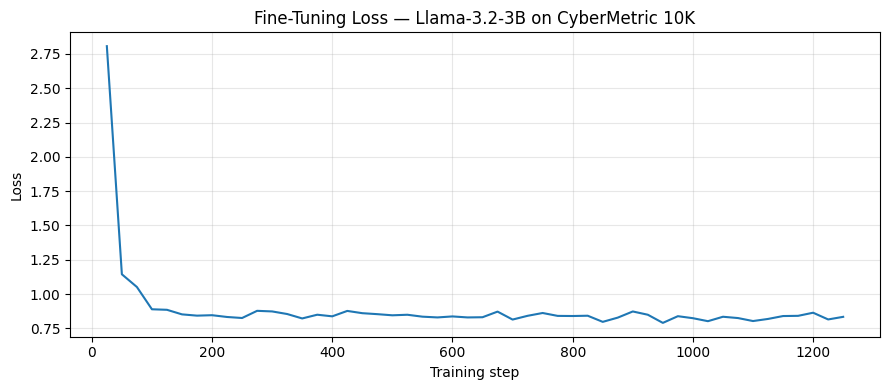

Saved as training_loss.png


In [15]:
loss_history = trainer.state.log_history
losses = [(h["step"], h["loss"]) for h in loss_history if "loss" in h]

if losses:
    steps, vals = zip(*losses)
    plt.figure(figsize=(9, 4))
    plt.plot(steps, vals, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Fine-Tuning Loss — Llama-3.2-3B on CyberMetric 10K")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_loss.png", dpi=150)
    plt.show()
    print("Saved as training_loss.png")

## 8. Evaluation After Fine-Tuning

In [16]:
print("=" * 47)
print("Llama-3.2-3B-Instruct after fine-tuning on CyberMetric 10K")
print("=" * 47)

ft_secqa_v1, ft_results_v1 = evaluate_mcq(
    model, tokenizer, secqa_v1, "SecQA v1"
)
ft_secqa_v2, ft_results_v2 = evaluate_mcq(
    model, tokenizer, secqa_v2, "SecQA v2"
)

ft_results = {
    "SecQA v1": ft_secqa_v1,
    "SecQA v2": ft_secqa_v2,
}
print("\nFine-tuned summary:")
for k, v in ft_results.items():
    print(f"  {k:10s}: {v:.2%}")

Llama-3.2-3B-Instruct after fine-tuning on CyberMetric 10K


Evaluating SecQA v1:   0%|          | 0/110 [00:00<?, ?it/s]

  SecQA v1: 110/110 = 100.00%


Evaluating SecQA v2:   0%|          | 0/100 [00:00<?, ?it/s]

  SecQA v2: 97/100 = 97.00%

Fine-tuned summary:
  SecQA v1  : 100.00%
  SecQA v2  : 97.00%


## 9. Compare Baseline vs. Fine-Tuned


In [17]:
import pandas as pd

rows = []
for bench in ["SecQA v1", "SecQA v2"]:
    base = baseline_results[bench]
    ft   = ft_results[bench]
    rows.append({
        "Benchmark":         bench,
        "Baseline":          f"{base:.2%}",
        "After fine-tuning": f"{ft:.2%}",
        "Δ (pp)":            f"{(ft - base)*100:+.1f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

df.to_csv("results_comparison.csv", index=False)
print("\nSaved as results_comparison.csv")

Benchmark Baseline After fine-tuning Δ (pp)
 SecQA v1   97.27%           100.00%   +2.7
 SecQA v2   95.00%            97.00%   +2.0

Saved as results_comparison.csv


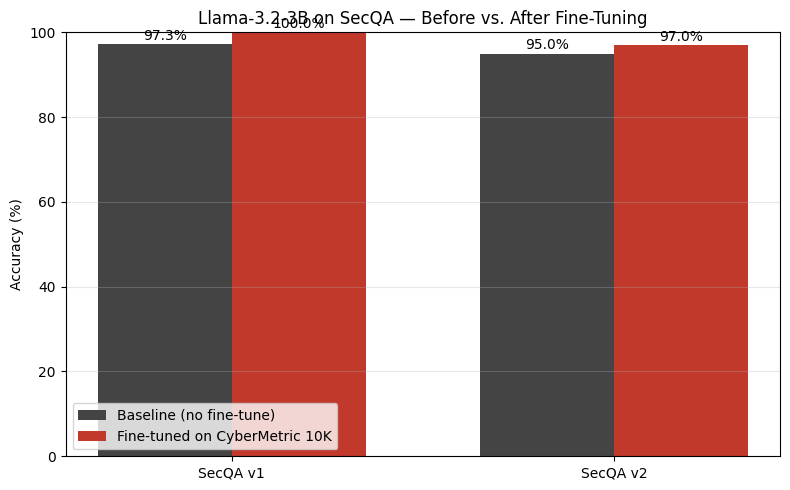

Saved as baseline_vs_finetuned.png


In [18]:
import numpy as np

benchmarks = ["SecQA v1", "SecQA v2"]
baseline_vals = [baseline_results[b] * 100 for b in benchmarks]
ft_vals       = [ft_results[b]       * 100 for b in benchmarks]

x = np.arange(len(benchmarks))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline (no fine-tune)", color="#444")
b2 = ax.bar(x + width/2, ft_vals,       width, label="Fine-tuned on CyberMetric 10K", color="#c0392b")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Llama-3.2-3B on SecQA — Before vs. After Fine-Tuning")
ax.set_xticks(x)
ax.set_xticklabels(benchmarks)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("baseline_vs_finetuned.png", dpi=150)
plt.show()
print("Saved as baseline_vs_finetuned.png")

## 10. Save Fine-Tuned Adapter

In [19]:
model.save_pretrained("llama-3.2-3b-cybermetric-lora")
tokenizer.save_pretrained("llama-3.2-3b-cybermetric-lora")
print("Saved adapter to ./llama-3.2-3b-cybermetric-lora/")
print("\nAdapter is small (~50–100 MB). To re-use it later:")
print("  - Load the same base model")
print("  - Apply the saved adapter via FastLanguageModel.from_pretrained(...)")

Saved adapter to ./llama-3.2-3b-cybermetric-lora/

Adapter is small (~50–100 MB). To re-use it later:
  - Load the same base model
  - Apply the saved adapter via FastLanguageModel.from_pretrained(...)


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
